# Quadrotor Path Planning and Closed-Loop Simulation

Plans a minimum-jerk trajectory through waypoints at constant altitude,
then simulates the closed-loop Modelica quadrotor model with and without
gyro bias disturbances.

In [17]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from concurrent.futures import ThreadPoolExecutor
import sympy as sp
import rumoca

from cp_reach.ir import DaeIR, ir_to_symbolic_statespace
from cp_reach.planning import plan_minimum_derivative_trajectory
from cp_reach.reachability import quadrotor_flatness

plt.rcParams['figure.dpi'] = 100

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# Configuration
MODELICA_FILE = "models/quadrotor_closed_loop2.mo"
MODEL_NAME = "QuadrotorClosedLoop2"
OUTPUT_DIR = "output_quadrotor"
D_GYRO = 0.1  # rad/s gyro bias disturbance amplitude

os.makedirs(OUTPUT_DIR, exist_ok=True)

## Compile Modelica Model

In [19]:
print(f"Compiling {MODELICA_FILE}...")
with open(MODELICA_FILE) as f:
    source = f.read()
json_str = rumoca.compile(source, MODEL_NAME)
ir = DaeIR.from_json_str(json_str)
ss = ir_to_symbolic_statespace(ir)
params = ir.get_param_defaults()
state_names = ss.get_state_names()
input_names = ss.get_input_names()
mass = params["mass"]
g = params["g"]
print(f"Compiled: {len(state_names)} states, {len(input_names)} inputs")
print(f"States: {state_names}")
print(f"Parameters: {params}")

Compiling models/quadrotor_closed_loop2.mo...
Compiled: 21 states, 27 inputs
States: ['px', 'py', 'pz', 'vx', 'vy', 'vz', 'R11', 'R12', 'R13', 'R21', 'R22', 'R23', 'R31', 'R32', 'R33', 'omega_x', 'omega_y', 'omega_z', 'vel_err_ix', 'vel_err_iy', 'vel_err_iz']
Parameters: {'mass': 2.496, 'Ixx': 0.0233, 'Iyy': 0.0344, 'Izz': 0.0527, 'g': 9.80665, 'Kp_px': 1.0, 'Kp_py': 1.0, 'Kp_pz': 1.5, 'Kp_vx': 2.0, 'Ki_vx': 0.1, 'Kp_vy': 2.0, 'Ki_vy': 0.1, 'Kp_vz': 2.5, 'Ki_vz': 0.1, 'Kr_x': 6.0, 'Kr_y': 6.0, 'Kr_z': 4.0, 'Kw_x': 5.0, 'Kw_y': 5.0, 'Kw_z': 4.0}


## Plan Trajectory

In [20]:
ALTITUDE = 1.0

waypoint_xyz = np.array([
    [0.0, 0.0, ALTITUDE],
    [7.04, -0.76, ALTITUDE],
    [10.04, 1.7, ALTITUDE],
    [10.22, 6.6, ALTITUDE],
    [13.33, 8.65, ALTITUDE],
    [20.15, 8.14, ALTITUDE],
    [19.6, -1.92, ALTITUDE],
])

waypoint_vel = np.array([
    [0.0, 0.0, 0.0],
    [2.37, 0.0, 0.0],
    [0.15, 2.67, 0.0],
    [0.49, 2.28, 0.0],
    [2.85, -0.23, 0.0],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
])

n_waypoints = len(waypoint_xyz)
n_segments = n_waypoints - 1
T_segments = np.array([4.67, 2.17, 1.84, 1.92, 5.5, 6.46])

# Convert to NED (negate z)
waypoint_ned = waypoint_xyz.copy()
waypoint_ned[:, 2] *= -1
vel_ned = waypoint_vel.copy()
vel_ned[:, 2] *= -1

# Minimum-snap trajectory (4th derivative) with 7th-order polynomials.
# C3 continuity (jerk continuous), omega_ref smooth, snap available for alpha_ref.
from cp_reach.planning.polynomial import compute_trajectory

print("Planning minimum-snap trajectory...")
trajectories = {}
for d, axis in enumerate(["x", "y", "z"]):
    bc = np.zeros((4, n_waypoints, 1))
    bc[0, :, 0] = waypoint_ned[:, d]  # position
    bc[1, :, 0] = vel_ned[:, d]       # velocity

    traj = plan_minimum_derivative_trajectory(
        bc=bc, min_deriv=4, poly_deg=7, T_guess=T_segments, bc_deriv=4
    )

    # Compute snap (4th derivative) from polynomial coefficients
    coeffs_d = traj.metadata["coeffs"][0]  # 1D trajectory
    T_opt = traj.metadata["segment_times"]
    snap_d = compute_trajectory(coeffs_d, T_opt, poly_deg=7, deriv=4)["x"]

    trajectories[axis] = {
        "t": traj.t,
        "pos": traj.x[:, 0],
        "vel": traj.metadata["derivatives"]["vel"][:, 0],
        "acc": traj.metadata["derivatives"]["acc"][:, 0],
        "jerk": traj.metadata["derivatives"]["jerk"][:, 0],
        "snap": snap_d,
    }

t_eval = trajectories["x"]["t"]
T_total = t_eval[-1]

p_ref = np.column_stack([trajectories[a]["pos"] for a in ["x", "y", "z"]])
v_ref = np.column_stack([trajectories[a]["vel"] for a in ["x", "y", "z"]])
a_ref = np.column_stack([trajectories[a]["acc"] for a in ["x", "y", "z"]])
jerk_ref = np.column_stack([trajectories[a]["jerk"] for a in ["x", "y", "z"]])
snap_ref = np.column_stack([trajectories[a]["snap"] for a in ["x", "y", "z"]])

# Remove duplicate time points at segment boundaries
unique_mask = np.concatenate([[True], np.diff(t_eval) > 0])
t_eval = t_eval[unique_mask]
p_ref = p_ref[unique_mask]
v_ref = v_ref[unique_mask]
a_ref = a_ref[unique_mask]
jerk_ref = jerk_ref[unique_mask]
snap_ref = snap_ref[unique_mask]

print(f"Trajectory: t=[0, {T_total:.1f}]s, {len(t_eval)} points, {n_segments} segments")

Planning minimum-snap trajectory...
Trajectory: t=[0, 22.6]s, 595 points, 6 segments


## Differential Flatness

In [21]:
N = len(t_eval)
Ixx_val, Iyy_val, Izz_val = params["Ixx"], params["Iyy"], params["Izz"]

# Analytical differential flatness: omega and alpha computed exactly from jerk/snap
flat_ref = quadrotor_flatness(
    p_ref, v_ref, a_ref, jerk_ref, mass, g,
    snap_ref=snap_ref,
    inertia=np.array([Ixx_val, Iyy_val, Izz_val]),
)
omega_ref = flat_ref["omega_ref"]
alpha_ref = flat_ref["alpha_ref"]
R_ref = flat_ref["R_ref"]
T_ref_val = flat_ref["T_ref"]
a_body_ref = flat_ref["a_body_ref"]
Mx_ff_ref = flat_ref["M_ff"][:, 0]
My_ff_ref = flat_ref["M_ff"][:, 1]
Mz_ff_ref = flat_ref["M_ff"][:, 2]

print(f"Thrust range: [{T_ref_val.min():.2f}, {T_ref_val.max():.2f}] N")
print(f"Max omega_ref: {np.max(np.abs(omega_ref), axis=0)} rad/s")
print(f"Max alpha_ref: {np.max(np.abs(alpha_ref), axis=0)} rad/s^2")
print(f"Max |Mx_ff|: {np.max(np.abs(Mx_ff_ref)):.6f} N*m")
print(f"Max |My_ff|: {np.max(np.abs(My_ff_ref)):.6f} N*m")
print(f"Max |Mz_ff|: {np.max(np.abs(Mz_ff_ref)):.6f} N*m")

Thrust range: [24.48, 25.90] N
Max omega_ref: [0.47204573 0.40497254 0.05976003] rad/s
Max alpha_ref: [3.28660231 3.38883894 0.23767754] rad/s^2
Max |Mx_ff|: 0.076578 N*m
Max |My_ff|: 0.116576 N*m
Max |Mz_ff|: 0.012526 N*m


## Reference Trajectory Plots

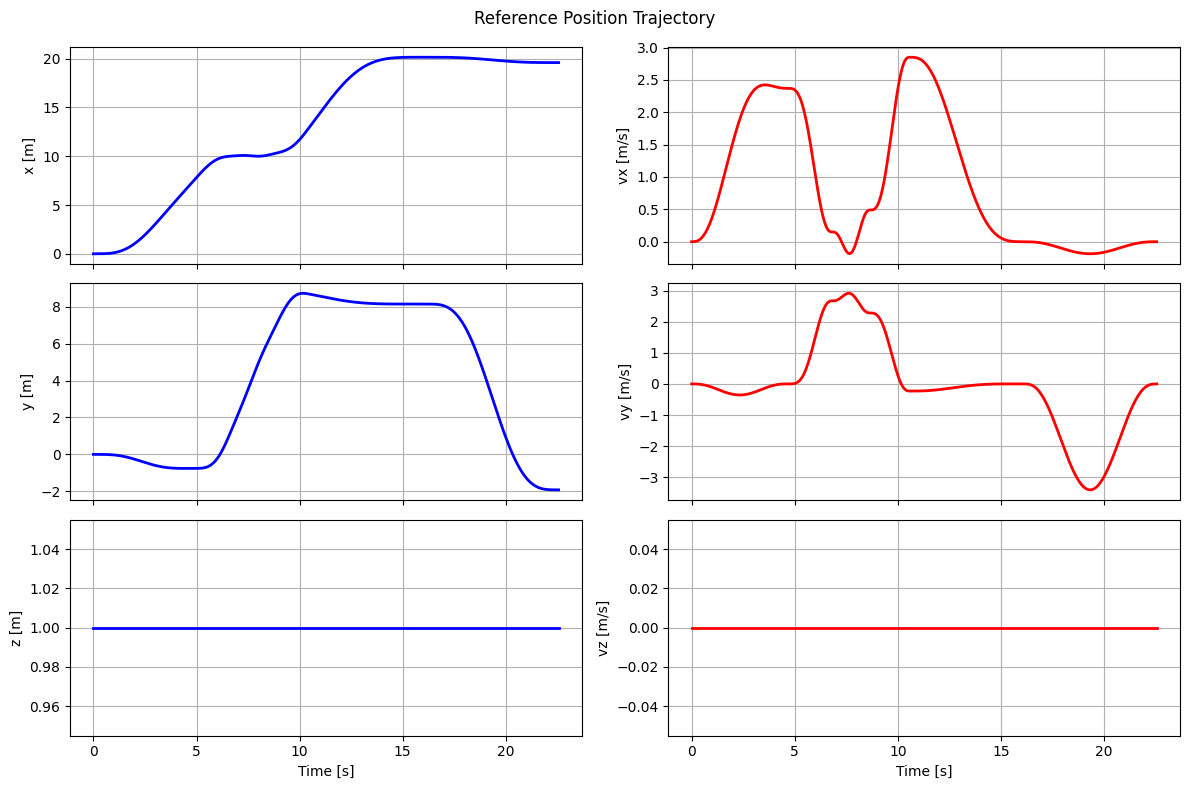

In [22]:
z_sign = [1, 1, -1]

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
for i, (plabel, vlabel) in enumerate(
    zip(["x [m]", "y [m]", "z [m]"], ["vx [m/s]", "vy [m/s]", "vz [m/s]"])
):
    axes[i, 0].plot(t_eval, z_sign[i] * p_ref[:, i], "b-", linewidth=2)
    axes[i, 0].set_ylabel(plabel)
    axes[i, 0].grid(True)
    axes[i, 1].plot(t_eval, z_sign[i] * v_ref[:, i], "r-", linewidth=2)
    axes[i, 1].set_ylabel(vlabel)
    axes[i, 1].grid(True)
axes[-1, 0].set_xlabel("Time [s]")
axes[-1, 1].set_xlabel("Time [s]")
fig.suptitle("Reference Position Trajectory")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ref_trajectory.png", dpi=150)
plt.show()

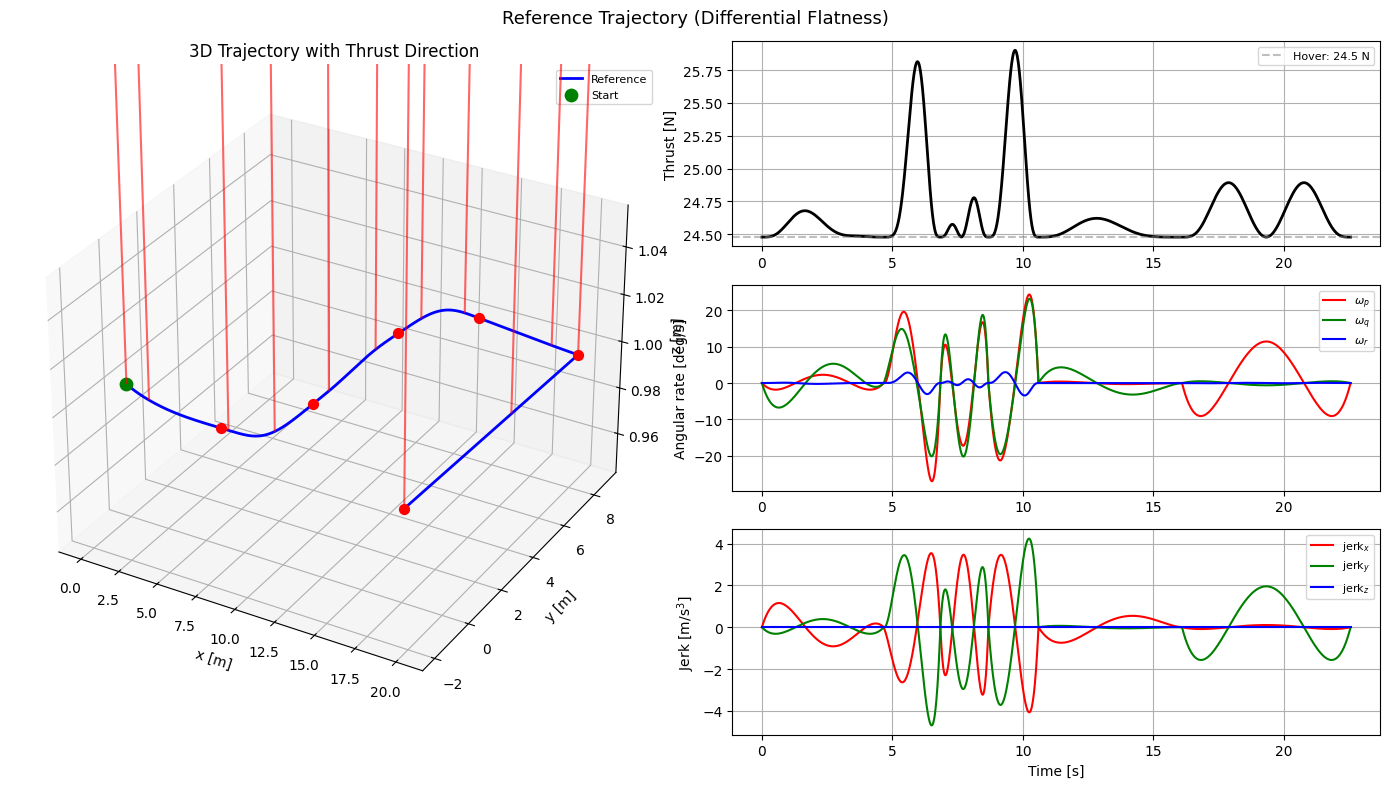

In [23]:
fig = plt.figure(figsize=(14, 8))

ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot(p_ref[:, 0], p_ref[:, 1], -p_ref[:, 2], 'b-', linewidth=2, label='Reference')
ax3d.scatter(*p_ref[0, :2], -p_ref[0, 2], color='g', s=80, zorder=5, label='Start')
for wp in waypoint_xyz[1:]:
    ax3d.scatter(*wp, color='r', s=50, zorder=5)

n_arrows = 12
arrow_idx = np.round(np.linspace(0, len(t_eval)-1, n_arrows)).astype(int)
for k in arrow_idx:
    thrust_dir = -R_ref[k, :, 2]
    scale = 0.3
    ax3d.quiver(p_ref[k, 0], p_ref[k, 1], -p_ref[k, 2],
                scale*thrust_dir[0], scale*thrust_dir[1], -scale*thrust_dir[2],
                color='r', alpha=0.6, arrow_length_ratio=0.15)

ax3d.set_xlabel('x [m]')
ax3d.set_ylabel('y [m]')
ax3d.set_zlabel('z [m]')
ax3d.set_title('3D Trajectory with Thrust Direction')
ax3d.legend(fontsize=8)

ax_T = fig.add_subplot(322)
ax_T.plot(t_eval, T_ref_val, 'k-', linewidth=2)
ax_T.axhline(mass * g, color='gray', linestyle='--', alpha=0.5, label=f'Hover: {mass*g:.1f} N')
ax_T.set_ylabel('Thrust [N]')
ax_T.legend(fontsize=8)
ax_T.grid(True)

ax_w = fig.add_subplot(324, sharex=ax_T)
for i, (label, color) in enumerate(zip(['p', 'q', 'r'], ['r', 'g', 'b'])):
    ax_w.plot(t_eval, np.rad2deg(omega_ref[:, i]), color=color, linewidth=1.5, label=f'$\\omega_{label}$')
ax_w.set_ylabel('Angular rate [deg/s]')
ax_w.legend(fontsize=8)
ax_w.grid(True)

ax_j = fig.add_subplot(326, sharex=ax_T)
for i, (label, color) in enumerate(zip(['x', 'y', 'z'], ['r', 'g', 'b'])):
    ax_j.plot(t_eval, jerk_ref[:, i], color=color, linewidth=1.5, label=f'jerk$_{label}$')
ax_j.set_ylabel('Jerk [m/s$^3$]')
ax_j.set_xlabel('Time [s]')
ax_j.legend(fontsize=8)
ax_j.grid(True)

fig.suptitle('Reference Trajectory (Differential Flatness)', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ref_trajectory_3d.png", dpi=150)
plt.show()

## Build Numerical Dynamics

In [24]:
print("Building dynamics function...")
full_dynamics = ss.f + ss.Bu
param_subs = {sp.Symbol(k): v for k, v in params.items()}
dynamics_with_params = full_dynamics.subs(param_subs)
dynamics_func = sp.lambdify(
    [ss.state_symbols, ss.input_symbols], dynamics_with_params, modules="numpy"
)

# Precompute input indices
_idx_p = [input_names.index(n) for n in ["px_ref", "py_ref", "pz_ref"]]
_idx_v = [input_names.index(n) for n in ["vx_ref", "vy_ref", "vz_ref"]]
_idx_a = [input_names.index(n) for n in ["ax_ref", "ay_ref", "az_ref"]]
_idx_R = [input_names.index(f"R{i+1}{j+1}_ref") for i in range(3) for j in range(3)]
_idx_w = [input_names.index(n) for n in ["omega_x_ref", "omega_y_ref", "omega_z_ref"]]
_idx_Mff = [input_names.index(n) for n in ["Mx_ff", "My_ff", "Mz_ff"]]
_idx_d = [input_names.index(n) for n in ["d_p", "d_q", "d_r"]]

# Reference channels: [p(3), v(3), a(3), R(9), omega(3), Mff(3)] = 24 channels
_ref_data = np.zeros((N, 24))
_ref_data[:, 0:3] = p_ref
_ref_data[:, 3:6] = v_ref
_ref_data[:, 6:9] = a_ref
_ref_data[:, 9:18] = R_ref.reshape(N, 9)
_ref_data[:, 18:21] = omega_ref
_ref_data[:, 21] = Mx_ff_ref
_ref_data[:, 22] = My_ff_ref
_ref_data[:, 23] = Mz_ff_ref
_ref_interp = interp1d(t_eval, _ref_data, axis=0, fill_value="extrapolate")
_ref_to_input = np.array(_idx_p + _idx_v + _idx_a + _idx_R + _idx_w + _idx_Mff, dtype=int)


def get_inputs(t, d_p=0.0, d_q=0.0, d_r=0.0):
    u = np.zeros(len(input_names))
    ref = _ref_interp(t)
    u[_ref_to_input] = ref
    u[_idx_d[0]] = d_p
    u[_idx_d[1]] = d_q
    u[_idx_d[2]] = d_r
    return u

print(f"Done. Inputs: {input_names}")

Building dynamics function...
Done. Inputs: ['px_ref', 'py_ref', 'pz_ref', 'vx_ref', 'vy_ref', 'vz_ref', 'ax_ref', 'ay_ref', 'az_ref', 'R11_ref', 'R12_ref', 'R13_ref', 'R21_ref', 'R22_ref', 'R23_ref', 'R31_ref', 'R32_ref', 'R33_ref', 'omega_x_ref', 'omega_y_ref', 'omega_z_ref', 'Mx_ff', 'My_ff', 'Mz_ff', 'd_p', 'd_q', 'd_r']


## Nominal Simulation

In [25]:
x0 = np.zeros(len(state_names))
x0[state_names.index("px")] = p_ref[0, 0]
x0[state_names.index("py")] = p_ref[0, 1]
x0[state_names.index("pz")] = p_ref[0, 2]
x0[state_names.index("R11")] = 1.0
x0[state_names.index("R22")] = 1.0
x0[state_names.index("R33")] = 1.0

t_span = (t_eval[0], t_eval[-1])

print("Running nominal simulation...")
nom_sol = solve_ivp(
    lambda t, s: np.array(dynamics_func(s, get_inputs(t))).flatten(),
    t_span, x0, t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-10,
)
print(f"Status: {nom_sol.message}")
print(
    f"Final pos: [{nom_sol.y[state_names.index('px'), -1]:.4f}, "
    f"{nom_sol.y[state_names.index('py'), -1]:.4f}, "
    f"{nom_sol.y[state_names.index('pz'), -1]:.4f}]"
)

Running nominal simulation...
Status: The solver successfully reached the end of the integration interval.
Final pos: [21.4314, -3.0979, -1.0744]


## Nominal vs Reference Trajectory

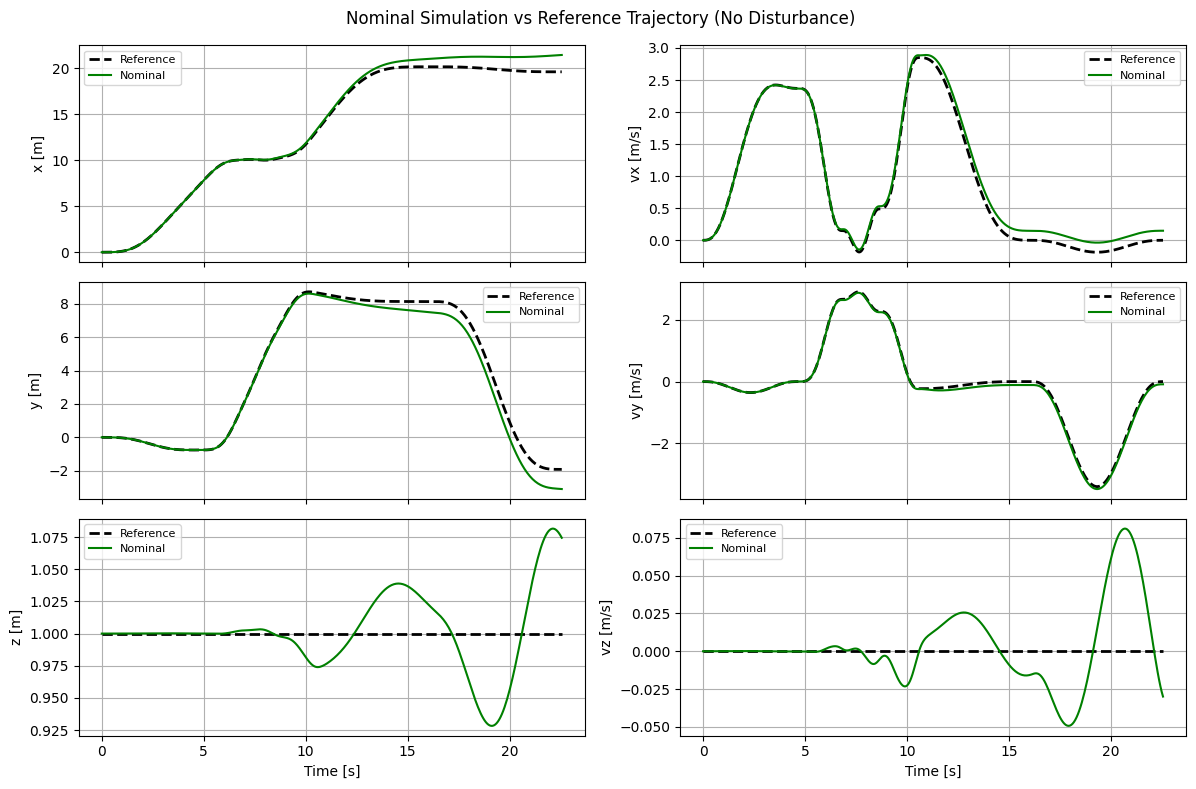

In [26]:
idx_px = state_names.index("px")
idx_py = state_names.index("py")
idx_pz = state_names.index("pz")
idx_vx = state_names.index("vx")
idx_vy = state_names.index("vy")
idx_vz = state_names.index("vz")

z_sign = [1, 1, -1]

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
pos_labels = ["x [m]", "y [m]", "z [m]"]
vel_labels = ["vx [m/s]", "vy [m/s]", "vz [m/s]"]
pos_indices = [idx_px, idx_py, idx_pz]
vel_indices = [idx_vx, idx_vy, idx_vz]

for i in range(3):
    axes[i, 0].plot(t_eval, z_sign[i] * p_ref[:, i], "k--", linewidth=2, label="Reference")
    axes[i, 0].plot(t_eval, z_sign[i] * nom_sol.y[pos_indices[i]], "g-", linewidth=1.5, label="Nominal")
    axes[i, 0].set_ylabel(pos_labels[i])
    axes[i, 0].legend(fontsize=8)
    axes[i, 0].grid(True)

    axes[i, 1].plot(t_eval, z_sign[i] * v_ref[:, i], "k--", linewidth=2, label="Reference")
    axes[i, 1].plot(t_eval, z_sign[i] * nom_sol.y[vel_indices[i]], "g-", linewidth=1.5, label="Nominal")
    axes[i, 1].set_ylabel(vel_labels[i])
    axes[i, 1].legend(fontsize=8)
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel("Time [s]")
axes[-1, 1].set_xlabel("Time [s]")
fig.suptitle("Nominal Simulation vs Reference Trajectory (No Disturbance)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/nominal_vs_ref.png", dpi=150)
plt.show()